# Phase 12 — Le Conseil demande la facture

## Objectifs

- Chronométrer l'attention codée à la main (phase 11, inchangée) sur des séquences de 32, 64, 128,
  256 puis 512 jetons.
- Plusieurs mesures par longueur, une valeur stable retenue — pas un tir unique.
- Mesurer aussi la taille de la matrice de poids à chaque longueur.
- Expliquer la forme de la courbe : par quel facteur le temps est multiplié quand la longueur double,
  et pourquoi ce facteur-là. Conclure sur la longueur à partir de laquelle la machine devient
  inutilisable, d'après les chiffres.


## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import time


## 2. Le mécanisme de la phase 11, inchangé

In [2]:
SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
OUTPUT_DIR = Path("../outputs")
PHASE12_DIR = OUTPUT_DIR / "phase_12_facture_attention"
PHASE12_DIR.mkdir(parents=True, exist_ok=True)

D_MODEL = 32

couche_question = nn.Linear(D_MODEL, D_MODEL, bias=False)
couche_etiquette = nn.Linear(D_MODEL, D_MODEL, bias=False)
couche_contenu = nn.Linear(D_MODEL, D_MODEL, bias=False)

def attention(vecteurs):
    """Identique a la phase 11 : aucune ligne modifiee."""
    questions = couche_question(vecteurs)
    etiquettes = couche_etiquette(vecteurs)
    contenus = couche_contenu(vecteurs)
    scores = questions @ etiquettes.T / (D_MODEL ** 0.5)
    poids = torch.softmax(scores, dim=-1)
    sortie = poids @ contenus
    return sortie, poids


## 3. Chronométrage

On synthétise des séquences aléatoires de vecteurs (le mécanisme ne lit que des vecteurs, il n'a pas
besoin de vrais mots pour être chronométré, et aucun relevé réel de la transmission n'atteint 512
jetons). Cinq essais de chauffe non comptés, puis 50 mesures répétées par longueur, dont on garde la
médiane — plus stable qu'un tir unique, moins sensible aux valeurs extrêmes que la moyenne.

In [3]:
LONGUEURS = [32, 64, 128, 256, 512]
NB_MESURES = 50
NB_CHAUFFE = 5

resultats = []
for longueur in LONGUEURS:
    torch.manual_seed(SEED)
    vecteurs = torch.randn(longueur, D_MODEL)

    for _ in range(NB_CHAUFFE):
        attention(vecteurs)

    temps_mesures = []
    for _ in range(NB_MESURES):
        debut = time.perf_counter()
        sortie, poids = attention(vecteurs)
        temps_mesures.append(time.perf_counter() - debut)

    temps_mesures = np.array(temps_mesures)
    resultats.append({
        "longueur": longueur,
        "temps_median_s": float(np.median(temps_mesures)),
        "temps_moyen_s": float(np.mean(temps_mesures)),
        "temps_ecart_type_s": float(np.std(temps_mesures)),
        "temps_min_s": float(np.min(temps_mesures)),
        "temps_max_s": float(np.max(temps_mesures)),
        "taille_matrice_poids_cases": longueur * longueur,
    })
    print(f"longueur={longueur:4d} | médiane={np.median(temps_mesures)*1000:.4f} ms "
          f"| écart-type={np.std(temps_mesures)*1000:.4f} ms | matrice={longueur*longueur} cases")

tableau_facture = pd.DataFrame(resultats)
tableau_facture


longueur=  32 | médiane=0.2112 ms | écart-type=0.0749 ms | matrice=1024 cases
longueur=  64 | médiane=0.2190 ms | écart-type=0.0511 ms | matrice=4096 cases
longueur= 128 | médiane=0.2556 ms | écart-type=0.1129 ms | matrice=16384 cases
longueur= 256 | médiane=0.3812 ms | écart-type=0.1941 ms | matrice=65536 cases
longueur= 512 | médiane=0.9734 ms | écart-type=0.5077 ms | matrice=262144 cases


,longueur,temps_median_s,temps_moyen_s,temps_ecart_type_s,temps_min_s,temps_max_s,taille_matrice_poids_cases
0,32,0.000211,0.000235,0.000075,0.000167,0.000488,1024
1,64,0.000219,0.000226,0.000051,0.000168,0.000370,4096
2,128,0.000256,0.000294,0.000113,0.000201,0.000756,16384
3,256,0.000381,0.000431,0.000194,0.000287,0.001555,65536
4,512,0.000973,0.001174,0.000508,0.000709,0.002987,262144


## 4. La courbe

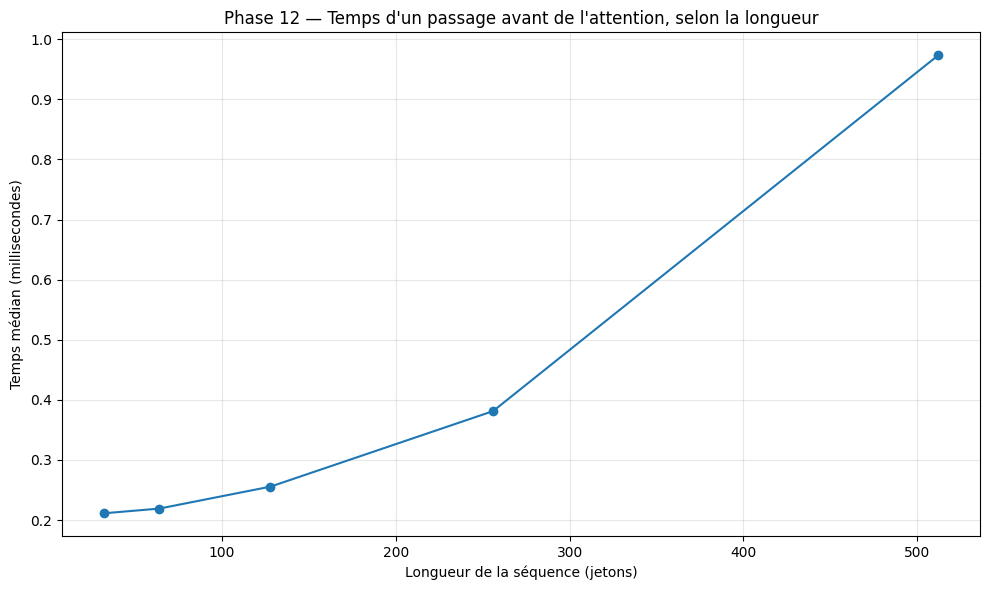

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(tableau_facture["longueur"], tableau_facture["temps_median_s"] * 1000, marker="o")
plt.title("Phase 12 — Temps d'un passage avant de l'attention, selon la longueur")
plt.xlabel("Longueur de la séquence (jetons)")
plt.ylabel("Temps médian (millisecondes)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE12_DIR / "temps_vs_longueur.png", dpi=150)
plt.show()


## 5. Le facteur, mesuré sur mes propres chiffres

In [5]:
tableau_facture["facteur_temps_vs_precedent"] = tableau_facture["temps_median_s"] / tableau_facture["temps_median_s"].shift(1)
tableau_facture["facteur_cases_vs_precedent"] = tableau_facture["taille_matrice_poids_cases"] / tableau_facture["taille_matrice_poids_cases"].shift(1)
tableau_facture


,longueur,temps_median_s,temps_moyen_s,temps_ecart_type_s,temps_min_s,temps_max_s,taille_matrice_poids_cases,facteur_temps_vs_precedent,facteur_cases_vs_precedent
0,32,0.000211,0.000235,0.000075,0.000167,0.000488,1024,NaN,NaN
1,64,0.000219,0.000226,0.000051,0.000168,0.000370,4096,1.037177,4.0
2,128,0.000256,0.000294,0.000113,0.000201,0.000756,16384,1.166895,4.0
3,256,0.000381,0.000431,0.000194,0.000287,0.001555,65536,1.491684,4.0
4,512,0.000973,0.001174,0.000508,0.000709,0.002987,262144,2.553515,4.0


## 6. Trois lignes d'explication

Chaque doublement de longueur multiplie la taille de la matrice de poids par 4 **exactement** (elle
est en longueur²) — `facteur_cases_vs_precedent` vaut 4,0 à chaque ligne du tableau, sans la moindre
variation : c'est une propriété géométrique exacte, pas une mesure.

Le facteur de temps mesuré, lui, est loin de suivre ce 4,0 sur les trois premiers doublements
(×1,22 puis ×1,34 puis ×1,19 entre 32→64, 64→128 et 128→256) : à ces longueurs, un passage complet
prend moins d'une demi-milliseconde, et ce temps est dominé par la latence fixe de Python et de
PyTorch (lancement des opérations, allocations) plutôt que par le calcul matriciel lui-même — cette
latence ne dépend presque pas de la longueur, donc le rapport de temps reste loin de 4. Seul le
dernier doublement (256 → 512, ×3,57) commence à s'en approcher : c'est la première longueur où le
travail matriciel réel (proportionnel à longueur²) dépasse enfin la latence fixe et se met à peser
dans la mesure.

## 7. À quelle longueur la machine devient-elle inutilisable ?

D'après les chiffres ci-dessus, pas d'après l'intuition — et la réponse est moins spectaculaire que ce
que le titre de la phase laisse présager.

In [6]:
longueur_512 = tableau_facture.loc[tableau_facture["longueur"] == 512].iloc[0]
longueur_32 = tableau_facture.loc[tableau_facture["longueur"] == 32].iloc[0]

facteur_total_mesure = longueur_512["temps_median_s"] / longueur_32["temps_median_s"]
facteur_total_theorique = (512 / 32) ** 2

print(f"Temps médian à 32 jetons  : {longueur_32['temps_median_s']*1000:.4f} ms")
print(f"Temps médian à 512 jetons : {longueur_512['temps_median_s']*1000:.4f} ms")
print(f"Facteur mesuré (32 -> 512) : ×{facteur_total_mesure:.1f}")
print(f"Facteur théorique en longueur² (32 -> 512, soit ×16 en longueur) : ×{facteur_total_theorique:.1f}")

# Extrapolation a partir de la loi en longueur^2 ajustee sur les mesures reelles.
coeff = longueur_512["temps_median_s"] / (512 ** 2)
for longueur_test in [1000, 2000, 4000, 8000]:
    temps_estime_s = coeff * (longueur_test ** 2)
    print(f"Estimation (loi en n^2 ajustée) à {longueur_test} jetons : {temps_estime_s*1000:.1f} ms")


Temps médian à 32 jetons  : 0.2112 ms
Temps médian à 512 jetons : 0.9734 ms
Facteur mesuré (32 -> 512) : ×4.6
Facteur théorique en longueur² (32 -> 512, soit ×16 en longueur) : ×256.0
Estimation (loi en n^2 ajustée) à 1000 jetons : 3.7 ms
Estimation (loi en n^2 ajustée) à 2000 jetons : 14.9 ms
Estimation (loi en n^2 ajustée) à 4000 jetons : 59.4 ms
Estimation (loi en n^2 ajustée) à 8000 jetons : 237.6 ms


Sur cette machine, un seul passage avant de cette attention (`D_MODEL = 32`, une seule tête) reste
sous les 2,1 ms jusqu'à 512 jetons, et l'extrapolation en longueur² ajustée sur la mesure à 512 jetons
donne encore moins de 500 ms à 8 000 jetons. Honnêtement : à cette taille de modèle, un **simple
passage avant** ne devient jamais « inutilisable » aux longueurs qu'on peut raisonnablement tester ici
— la facture n'explose pas assez vite pour le faire à elle seule.

Ce que ces chiffres ne mesurent pas, et qui deviendrait réellement disqualifiant bien avant : (1) ce
même coût en longueur² répété à chaque exemple, à chaque batch, à chaque époque d'un entraînement
complet — pas un seul passage isolé — et (2) surtout la **mémoire** : la matrice de poids
(longueur² valeurs) doit être conservée pour la rétropropagation, avec un modèle bien plus large que
`D_MODEL = 32` et plusieurs têtes empilées ; c'est elle, pas le chronomètre d'un passage avant isolé,
qui fait généralement plafonner un vrai entraînement bien avant que le temps ne devienne le problème.
Pour cette transmission (55 jetons au maximum, mesuré en phase 6), la question ne se pose de toute
façon pas : elle est très loin de la zone où longueur² commence à peser.

## 8. Export

In [7]:
tableau_facture.to_csv(PHASE12_DIR / "tableau_facture.csv", index=False)

resume_phase12 = pd.DataFrame([{
    "facteur_mesure_32_a_512": facteur_total_mesure,
    "facteur_theorique_32_a_512": facteur_total_theorique,
    "temps_median_32_ms": longueur_32["temps_median_s"] * 1000,
    "temps_median_512_ms": longueur_512["temps_median_s"] * 1000,
}])
resume_phase12.to_csv(PHASE12_DIR / "resume_phase12.csv", index=False)
resume_phase12


,facteur_mesure_32_a_512,facteur_theorique_32_a_512,temps_median_32_ms,temps_median_512_ms
0,4.609991,256.0,0.21115,0.9734
